# SmartCart Day 3 - Recognize & Diagnose

Detection found *where* products are; now we learn *what* each one is. We train a tiny linear head on frozen features, then **diagnose** it - per -class accuracy, confusions, and an explanation heatmap - because a checkout that silently misreads items is worse than useless.

In [1]:
# 1) Runtime setup
# Install only the packages used in this notebook.
%pip install -q timm

import os

# The cross-day bundle lives in a local folder (was a Google Drive mount on Colab).
# Day 1 (day_1/Day1_acquire_index.ipynb) writes to this same path for continuity.
BUNDLE_DIR = os.path.expanduser('~/SmartCart_bundle')


Note: you may need to restart the kernel to use updated packages.


### Embedded toolkit

This hidden cell defines the helper functions used below. Run it once after setup.

In [2]:
from __future__ import annotations
import json
import os
import pathlib
import subprocess
import numpy as np
import pandas as pd
HERE = pathlib.Path.cwd()  # embedded in-notebook: no __file__, anchor on the working dir
GROCERY_DATASET_URL = 'https://github.com/marcusklasson/GroceryStoreDataset'

class Bundle:
    """Small local folder that carries artifacts from one day to the next."""

    def __init__(self, root: str):
        self.root = pathlib.Path(root)
        self.root.mkdir(parents=True, exist_ok=True)
        self.manifest = {'version': 1, 'class_list': [], 'artifacts': {}}

    def put_table(self, name, df: pd.DataFrame):
        df.to_csv(self.root / name, index=False)
        self._note(name)

    def get_table(self, name) -> pd.DataFrame:
        return pd.read_csv(self.root / name)

    def put_array(self, name, arr: np.ndarray):
        np.save(self.root / name, arr)
        self._note(name)

    def get_array(self, name) -> np.ndarray:
        p = self.root / name
        return np.load(p if p.suffix == '.npy' else p.with_suffix('.npy'))

    def _note(self, name):
        self.manifest['artifacts'][name] = True

    def save(self):
        (self.root / 'manifest.json').write_text(json.dumps(self.manifest, indent=2))

    def load(self):
        p = self.root / 'manifest.json'
        if p.exists():
            self.manifest = json.loads(p.read_text())
        return self

def open_bundle(drive_dir=None) -> Bundle:
    """Open the cross-day local bundle. If it is new, start with an empty manifest."""
    return Bundle(drive_dir or os.path.expanduser('~/SmartCart_bundle')).load()

def save_bundle(b: Bundle):
    b.save()
    print(f'[bundle] saved -> {b.root}')

def open_grocery_dataset():
    """Clone or reuse the real GroceryStoreDataset and return (tier, root_dir)."""
    candidates = [
        HERE / 'GroceryStoreDataset',
        HERE.parent / 'day_2' / 'GroceryStoreDataset',
        HERE.parent / 'GroceryStoreDataset',
    ]
    for root in candidates:
        if (root / 'dataset' / 'classes.csv').exists():
            print('using cached GroceryStoreDataset:', root)
            print('using data tier: github')
            print('data root:', root)
            print('OK: using real GroceryStoreDataset images.')
            return ('github', str(root))
    root = HERE / 'GroceryStoreDataset'
    print('cloning GroceryStoreDataset from:', GROCERY_DATASET_URL)
    subprocess.run(['git', 'clone', '--depth', '1', GROCERY_DATASET_URL, str(root)], check=True)
    if not (root / 'dataset' / 'classes.csv').exists():
        raise RuntimeError('GroceryStoreDataset clone is incomplete. Check network access and rerun.')
    print('using data tier: github')
    print('data root:', root)
    print('OK: using real GroceryStoreDataset images.')
    return ('github', str(root))

def open_sg_dataset(sg_root=None):
    """SG innovation swap for open_grocery_dataset(): point at our own Singapore
    catalog (sg_data/) instead of the course-default GroceryStoreDataset. Returns
    the same (tier, root_dir) shape so downstream code doesn't need to branch."""
    root = pathlib.Path(sg_root or (HERE.parent / 'sg_data'))
    if not (root / 'labels.csv').exists():
        raise RuntimeError(f'sg_data not found at {root} (expected labels.csv). '
                            f'Check the path or run Week4/sg_data/collect_sg_groceries.py first.')
    print('using data tier: sg_data (Singapore catalog)')
    print('data root:', root)
    print('OK: using real FairPrice-sourced Singapore product images.')
    return ('sg_data', str(root))

def list_images(root, per_class=None):
    """Return a DataFrame with columns path,coarse,fine.
    Handles two layouts: GroceryStoreDataset's train/val/test split folders, and
    sg_data's flat labels.csv (path,coarse,fine) — detected by which one exists."""
    root = pathlib.Path(root)
    labels_csv = root / 'labels.csv'
    if labels_csv.exists():
        df = pd.read_csv(labels_csv)
        df['path'] = df['path'].map(lambda p: p if pathlib.Path(p).is_absolute() else str((root / p).resolve()))
    else:
        rows = []
        for split in ('train', 'val', 'test'):
            for p in (root / 'dataset' / split).rglob('*.jpg'):
                rows.append({'path': str(p), 'coarse': p.parent.parent.name, 'fine': p.parent.name})
        df = pd.DataFrame(rows)
    if per_class and len(df):
        df = df.groupby('fine', group_keys=False).head(per_class).reset_index(drop=True)
    return df

def load_backbone(name='vit_small_patch14_dinov2.lvd142m', device='cpu'):
    """Frozen DINOv2-small feature extractor."""
    import timm
    m = timm.create_model(name, pretrained=True, num_classes=0, dynamic_img_size=True).eval().to(device)
    for p in m.parameters():
        p.requires_grad_(False)
    return m

def extract_features(model, batches, device=None) -> np.ndarray:
    """Run image batches through a frozen backbone and return numpy features."""
    import torch
    if device is None:
        try:
            device = next(model.parameters()).device
        except (AttributeError, StopIteration):
            device = 'cpu'
    outs = []
    with torch.no_grad():
        for xb in batches:
            y = model(xb.to(device))
            outs.append(y.detach().cpu().numpy().astype('float32'))
    return np.concatenate(outs, 0)

class LinearHead:
    """Tiny torch linear classifier trained on frozen image features."""

    def __init__(self, in_dim, n_classes):
        import torch
        import torch.nn as nn
        self.net = nn.Linear(in_dim, n_classes)
        self.torch = torch

    def fit(self, X, y, epochs=30, lr=0.01):
        t = self.torch
        opt = t.optim.Adam(self.net.parameters(), lr=lr)
        lossf = t.nn.CrossEntropyLoss()
        Xt = t.tensor(X)
        yt = t.tensor(y)
        for _ in range(epochs):
            opt.zero_grad()
            loss = lossf(self.net(Xt), yt)
            loss.backward()
            opt.step()
        return self

    def predict(self, X):
        with self.torch.no_grad():
            return self.net(self.torch.tensor(X)).argmax(1).numpy()

def save_head(head: LinearHead, path):
    import torch
    torch.save({'state_dict': head.net.state_dict(), 'in_dim': head.net.in_features, 'n_classes': head.net.out_features}, path)
    return path
# --- helpers are now available as plain functions/classes in this notebook ---
print('SmartCart toolkit ready')


SmartCart toolkit ready


In [3]:
# 2) Load the cross-day bundle
# The bundle stores artifacts we create during the week: labels, indexes, weights, ONNX files.
# It is NOT the image dataset. Images are loaded in the next data-source cell.
b = open_bundle(BUNDLE_DIR)
print('bundle:', b.root)
print('artifacts:', list(b.manifest.get('artifacts', {})))


bundle: C:\Users\Max\SmartCart_bundle
artifacts: ['gallery_index.npy', 'gallery_meta.csv', 'catalog_prices.csv', 'labels.csv', 'sample_scene.jpg', 'detector.pt', 'detector_v0.pt', 'crops_manifest.csv']


In [4]:
# 3) Select the image data source
# SG innovation swap (D1): use our own Singapore catalog instead of the course
# default. Both return the same (tier, root) shape, so nothing downstream changes —
# classes/n_classes are derived from the data at runtime, so the head automatically
# becomes a 25-way classifier on sg_data.
USE_SG_CATALOG = True
if USE_SG_CATALOG:
    tier, root = open_sg_dataset()
else:
    tier, root = open_grocery_dataset()


using data tier: sg_data (Singapore catalog)
data root: c:\Users\Max\Desktop\SNAIC_Week4_SmartCart-main\sg_data
OK: using real FairPrice-sourced Singapore product images.


## Load the training set (annotated images) + any detector crops

**What:** Re-list the balanced product images for *this* runtime; load Day 2's saved detector crops for a real-world check.

**Why:** The classifier learns from clean, balanced labels - not from however many crops the detector found. We re-list rather than trust saved paths because each day is a fresh VM.

**Watch for:** Detector crops live in the Drive bundle; if the count is 0, rerun Day 2 with the updated notebook.

In [5]:
import os
# Train from clean labelled product photos re-listed in this runtime.
per_class = int(os.environ.get('SC_PER_CLASS','40'))
data = list_images(root, per_class=per_class).rename(columns={'path':'crop_path'})
assert len(data) > 0, 'No images found in the selected data source. Re-run the data-source cell.'
print('training images:', len(data))
# Optional real-world check: Day 2 saved detector crops into the Drive bundle.
try:
    crops = b.get_table('crops_manifest.csv')
    crops = crops[crops.crop_path.apply(os.path.exists)]
    # Crops must belong to the SAME catalog we're training on. If the bundle still
    # holds crops from a run on the other dataset (e.g. 81-class default while we
    # train on 25-class sg_data), drop them and say so — a silent 0% "real-world
    # check" against mismatched labels would be meaningless.
    known = set(data.fine.unique())
    stale = crops[~crops.fine.isin(known)]
    if len(stale):
        print(f'ignoring {len(stale)} detector crops with labels not in this catalog '
              f'(bundle crops are from a different data source — re-run Day 2 with USE_SG_CATALOG matching)')
    crops = crops[crops.fine.isin(known)]
    crops = crops if len(crops) else None
    print('detector crops available for a real-world check:', 0 if crops is None else len(crops))
except Exception:
    crops = None; print('no detector crops yet (Day 2 skipped) — training on annotated images only')


training images: 998
detector crops available for a real-world check: 157


## Features + split

**What:** Embed every image, integer-encode the fine labels, and make a (guarded) stratified train/val split.

**Why:** Frozen features + a linear head is a strong, fast baseline; stratifying keeps rare classes in both sides.

**Watch for:** If any class has <2 samples we drop stratification automatically so the split never crashes.

In [6]:
import torch, torchvision.transforms.v2 as T
from PIL import Image
import numpy as np
# Shared image preprocessing for DINOv2.
TF = T.Compose([T.ToImage(), T.Resize((224,224)), T.ToDtype(torch.float32, scale=True),
                T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
def feats_of(paths, model, bs=16):
    """Embed image files in small batches and return an (N, D) numpy array."""
    out=[]
    for i in range(0,len(paths),bs):
        xs=torch.stack([TF(Image.open(p).convert('RGB')) for p in paths[i:i+bs]])
        out.append(extract_features(model,[xs]))
    return np.concatenate(out,0)
from sklearn.model_selection import train_test_split
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('using device:', device)
model = load_backbone(device=device)
# Embed each image once, then train only a small linear classifier.
feats = feats_of(list(data.crop_path), model)
classes = sorted(data.fine.unique().tolist())
cls_to_i = {c:i for i,c in enumerate(classes)}
y = np.array([cls_to_i[f] for f in data.fine])
# Stratify only when every class has enough examples.
counts = np.bincount(y, minlength=len(classes))
strat = y if counts.min() >= 2 else None  # stratify only when every class has >=2 samples
Xtr,Xval,ytr,yval = train_test_split(feats, y, test_size=0.3, random_state=0, stratify=strat)
print('train', Xtr.shape, 'val', Xval.shape, '|', len(classes), 'classes')


using device: cuda


c:\Users\Max\Desktop\SNAIC_Week4_SmartCart-main\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


train (698, 384) val (300, 384) | 25 classes


## Train the head

**What:** Fit the `LinearHead` on the training features and report validation accuracy.

**Why:** This is the actual product classifier - small enough to export and ship on Day 5.

**Watch for:** If val accuracy is near chance, features or labels are misaligned - stop and check.

In [7]:
head = LinearHead(in_dim=feats.shape[1], n_classes=len(classes)).fit(Xtr, ytr, epochs=200)
val_pred = head.predict(Xval)
# Simple top-1 validation accuracy.
acc = float((val_pred == yval).mean())
print('validation accuracy:', round(acc, 3))


validation accuracy: 0.92


## Explainability + confidence toolkit (ported from Hongming's D5 work)

**What:** Four reusable pieces: (1) load Day 1's gallery so explanations can show "what the model thinks this looks similar to"; (2) `score_image()` — ONE shared features→logits→softmax-confidence path used by both recognition and explanation, so the two never compute confidence differently; (3) `classify_with_confidence()` — rejects low-confidence predictions as `unknown_item` instead of silently returning a wrong top-1; (4) `explain_prediction()`/`plot_explanation()` — the occlusion heatmap refactored to run **batched** (~2 forward calls instead of 49) on **any** image path, not a hardcoded validation index — the same code path a live Day 5 upload uses.

**Watch for:** the 0.5 threshold default is a placeholder here; Day 5a calibrates the real serving threshold on detector crops and saves it to the bundle as `confidence_threshold.json`.

In [8]:
import matplotlib.pyplot as plt

class EmbeddingIndex:
    """Cosine nearest-neighbor index over catalog/gallery embeddings (same class Day 1
    uses to build gallery_index.npy / gallery_meta.csv - loaded here, not rebuilt)."""

    def __init__(self):
        self._nn = None
        self.meta = []

    def build(self, feats: np.ndarray, meta: list):
        from sklearn.neighbors import NearestNeighbors
        f = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-08)
        self._nn = NearestNeighbors(n_neighbors=min(10, len(f)), metric='cosine').fit(f)
        self.meta = meta
        self._feats = f
        return self

    def query(self, q: np.ndarray, k=5):
        qn = q / (np.linalg.norm(q, axis=1, keepdims=True) + 1e-08)
        dist, idx = self._nn.kneighbors(qn, n_neighbors=min(k, len(self.meta)))
        return [[{**self.meta[j], 'score': float(1 - d)} for d, j in zip(drow, irow)] for drow, irow in zip(dist, idx)]

    @classmethod
    def load(cls, b, prefix='gallery'):
        feats = b.get_array(f'{prefix}_index.npy')
        meta = b.get_table(f'{prefix}_meta.csv').to_dict('records')
        return cls().build(feats, meta)

try:
    gallery = EmbeddingIndex.load(b)
    print('gallery loaded:', len(gallery.meta), 'classes')
except Exception as e:
    gallery = None
    print('no gallery in bundle (run Day 1 first) - explanations will skip neighbors:', e)

def find_similar_products(feat, gallery, k=3):
    """Nearest catalog images to a single query embedding.
    Answers a different question than the occlusion heatmap: not 'which pixels mattered'
    but 'what does the model think this looks similar to' - both shown together in
    plot_explanation() below."""
    if gallery is None:
        return None
    return gallery.query(feat.reshape(1, -1), k=k)[0]

def score_image(img_path, model, head, classes):
    """Single shared scoring function: features -> logits -> softmax confidence.
    Used by BOTH the confidence-threshold check (Recognition) and the explanation
    heatmap (Explainability), so the two areas never compute confidence differently."""
    feat = feats_of([img_path], model)
    logits = head.net(head.torch.tensor(feat)).detach().numpy()[0]
    probs = np.exp(logits - logits.max())
    probs = probs / probs.sum()
    pred_id = int(np.argmax(logits))
    return {
        'pred_id': pred_id,
        'pred_name': classes[pred_id],
        'confidence': float(probs[pred_id]),
        'logits': logits,
        'feat': feat[0],
    }

def classify_with_confidence(img_path, model, head, classes, threshold=0.5):
    """Recognition: reject low-confidence predictions as 'unknown_item' instead of
    silently returning a wrong top-1 guess."""
    s = score_image(img_path, model, head, classes)
    if s['confidence'] < threshold:
        return {'label': 'unknown_item', 'confidence': s['confidence'], 'raw_pred': s['pred_name']}
    return {'label': s['pred_name'], 'confidence': s['confidence']}

def make_occlusion_batch(img, grid=7, patch=32, fill=(128, 128, 128)):
    """Generate every occluded variant of `img` as a list of PIL images, one per grid cell."""
    variants = []
    for r in range(grid):
        for c in range(grid):
            occ = img.copy()
            block = Image.new('RGB', (patch, patch), color=fill)
            occ.paste(block, (c * patch, r * patch))
            variants.append(occ)
    return variants

def explain_prediction(img_path, model, head, classes, grid=7, patch=32, batch_size=32, gallery=None, k=3):
    """Occlusion-sensitivity heatmap + confidence for ANY image (not tied to a
    hardcoded validation index - works the same for a live Day 5 app upload).
    Runs all grid*grid occluded variants through the backbone in BATCHES instead
    of one occlusion = one forward pass (was 49 separate calls; now ~2 calls at
    batch_size=32)."""
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    s = score_image(img_path, model, head, classes)
    pred_id, base_score = s['pred_id'], float(s['logits'][s['pred_id']])

    variants = make_occlusion_batch(img, grid=grid, patch=patch)
    scores = []
    for i in range(0, len(variants), batch_size):
        batch_imgs = variants[i:i + batch_size]
        x = torch.stack([TF(v) for v in batch_imgs])
        f = extract_features(model, [x])
        logits = head.net(head.torch.tensor(f)).detach().numpy()
        scores.extend(logits[:, pred_id].tolist())

    heat = (base_score - np.array(scores)).clip(min=0).reshape(grid, grid)
    heat = heat / (heat.max() + 1e-6)

    return {
        'img': img,
        'heatmap': heat,
        'pred_name': s['pred_name'],
        'pred_id': pred_id,
        'confidence': s['confidence'],
        'neighbors': find_similar_products(s['feat'], gallery, k=k),
    }

def plot_explanation(result, true_name=None):
    """Render the image + heatmap overlay + nearest catalog matches (if a gallery was
    passed to explain_prediction), with confidence shown in the title."""
    img, heat = result['img'], result['heatmap']
    neighbors = result.get('neighbors')
    n_extra = len(neighbors) if neighbors else 0

    fig, axes = plt.subplots(1, 2 + n_extra, figsize=(4 * (2 + n_extra), 4))
    axes = np.atleast_1d(axes)

    title_left = f"true: {true_name}\npred: {result['pred_name']}" if true_name else f"pred: {result['pred_name']}"
    axes[0].imshow(img); axes[0].set_title(title_left); axes[0].axis('off')

    heat_img = Image.fromarray((heat * 255).astype('uint8')).resize((224, 224))
    axes[1].imshow(img)
    axes[1].imshow(heat_img, cmap='magma', alpha=0.55)
    axes[1].set_title(f"confidence: {result['confidence']:.1%}"); axes[1].axis('off')

    if neighbors:
        for i, nb in enumerate(neighbors):
            ax = axes[2 + i]
            try:
                ax.imshow(Image.open(nb['iconic']).convert('RGB'))
            except Exception:
                ax.text(0.5, 0.5, 'image\nmissing', ha='center', va='center')
            ax.set_title(f"{nb['fine']}\nsim {nb['score']:.2f}", fontsize=9)
            ax.axis('off')

    plt.tight_layout()

print('explainability + confidence toolkit ready')


gallery loaded: 25 classes
explainability + confidence toolkit ready


## Error analysis

**What:** Build a confusion matrix, a per-class accuracy table, and surface the hardest confusions.

**Why:** Aggregate accuracy hides which SKUs fail; the checkout cares about *which* items it gets wrong.

**Watch for:** Low-n classes have noisy accuracy - read them alongside their support count.

,fine,acc,n
0,Maggi-Curry-Noodles,0.583333,12
1,KCT-Chilli-Sauce,0.666667,12
2,Koka-Noodles,0.666667,12
3,Meiji-Fresh-Milk,0.750000,12
4,Chye-Sim,0.833333,12
5,Prima-Taste-Laksa,0.833333,12
6,Camel-Nuts,0.916667,12
7,FN-Seasons,0.916667,12
8,Ice-Mountain-Water,0.916667,12
9,Pokka-Green-Tea,0.916667,12


,true,predicted,count
0,KCT-Chilli-Sauce,Meiji-Fresh-Milk,4
1,Chye-Sim,Kailan,2
2,Koka-Noodles,Khong-Guan-Biscuits,2
3,Maggi-Curry-Noodles,Camel-Nuts,2
4,Maggi-Curry-Noodles,Gardenia-White-Bread,2
5,Meiji-Fresh-Milk,KCT-Chilli-Sauce,2
6,Camel-Nuts,Khong-Guan-Biscuits,1
7,FN-Seasons,Yeos-Chrysanthemum-Tea,1
8,Ice-Mountain-Water,Chye-Sim,1
9,Koka-Noodles,Camel-Nuts,1


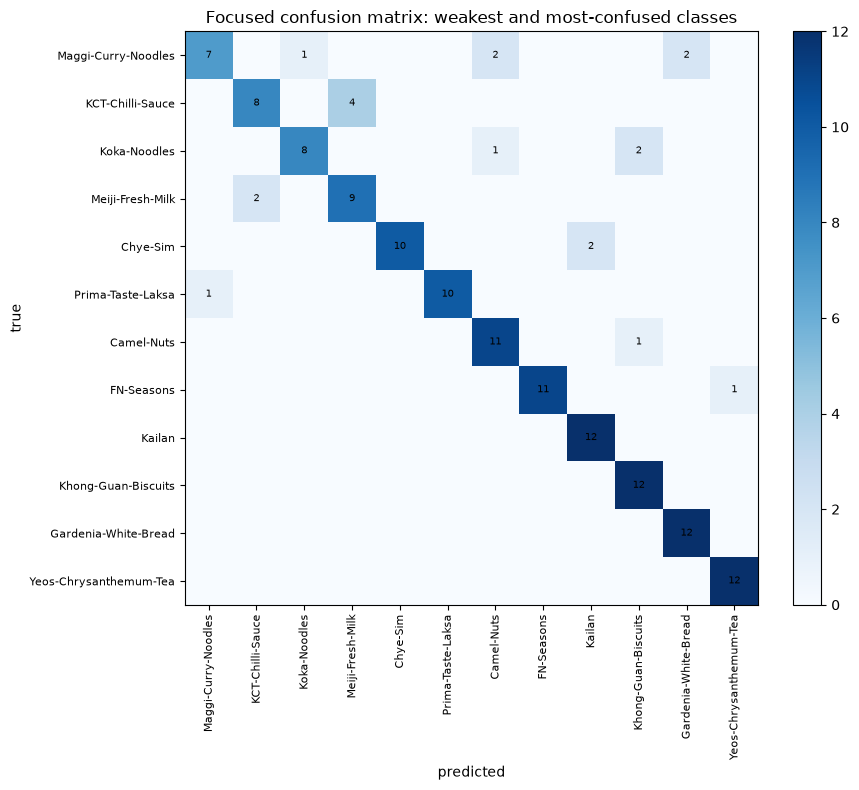

In [9]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
# Rows are true classes; columns are predicted classes.
cm = confusion_matrix(yval, val_pred, labels=list(range(len(classes))))
pcm = pd.DataFrame({
    'fine': classes,
    'acc': [cm[i,i]/cm[i].sum() if cm[i].sum() else 0.0 for i in range(len(classes))],
    'n': [int(cm[i].sum()) for i in range(len(classes))]})
display(pcm.sort_values(['acc','n']).reset_index(drop=True))
conf = [(classes[i], classes[j], int(cm[i,j])) for i in range(len(classes)) for j in range(len(classes)) if i!=j and cm[i,j]>0]
conf_df = pd.DataFrame(sorted(conf, key=lambda t:-t[2]), columns=['true','predicted','count'])
display(conf_df.head(12) if len(conf_df) else pd.DataFrame(columns=['true','predicted','count']))
# A full 81x81 matrix is unreadable. Plot a focused matrix around weak/confused classes.
weak = pcm.sort_values(['acc','n']).head(8).fine.tolist()
confused = list(dict.fromkeys(conf_df.head(8)[['true','predicted']].to_numpy().ravel().tolist())) if len(conf_df) else []
focus = list(dict.fromkeys(weak + confused))[:14]
focus_idx = [classes.index(c) for c in focus]
focus_cm = cm[np.ix_(focus_idx, focus_idx)]
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(focus_cm, cmap='Blues')
ax.set_xticks(range(len(focus))); ax.set_yticks(range(len(focus)))
ax.set_xticklabels(focus, rotation=90, fontsize=8); ax.set_yticklabels(focus, fontsize=8)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('Focused confusion matrix: weakest and most-confused classes')
for r in range(len(focus)):
    for c in range(len(focus)):
        if focus_cm[r,c]: ax.text(c, r, int(focus_cm[r,c]), ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()


## Close the loop: classify Day 2's real detector crops

**What:** Run the trained head on the actual crops the detector produced - clean-trained, real-tested.

**Why:** This is the real pipeline: a classifier trained on tidy labels must survive messy detections.

**Watch for:** Few crops at low detector epochs is expected; the number climbs with Day 2's full training.

In [10]:
if crops is not None and len(crops):
    cf = feats_of(list(crops.crop_path), model)
    pred = [classes[i] for i in head.predict(cf)]
    correct = sum(p==t for p,t in zip(pred, crops.fine))
    print(f'on {len(crops)} real detector crops: {correct}/{len(crops)} correct')
else:
    print('no detector crops to test (run Day 2 first).')


on 157 real detector crops: 143/157 correct


## Explain the call

**What:** Show a misread validation image and an occlusion heatmap that plays the same teaching role as Grad-CAM.

**Why:** The classifier head sits on frozen DINOv2 features, so occlusion is more robust here than forcing CNN-style Grad-CAM onto a ViT.

**Watch for:** Bright regions are patches where hiding pixels changes the predicted-class score most.

{'label': 'Ayam-Brand-Sardines', 'confidence': 0.9970576763153076}


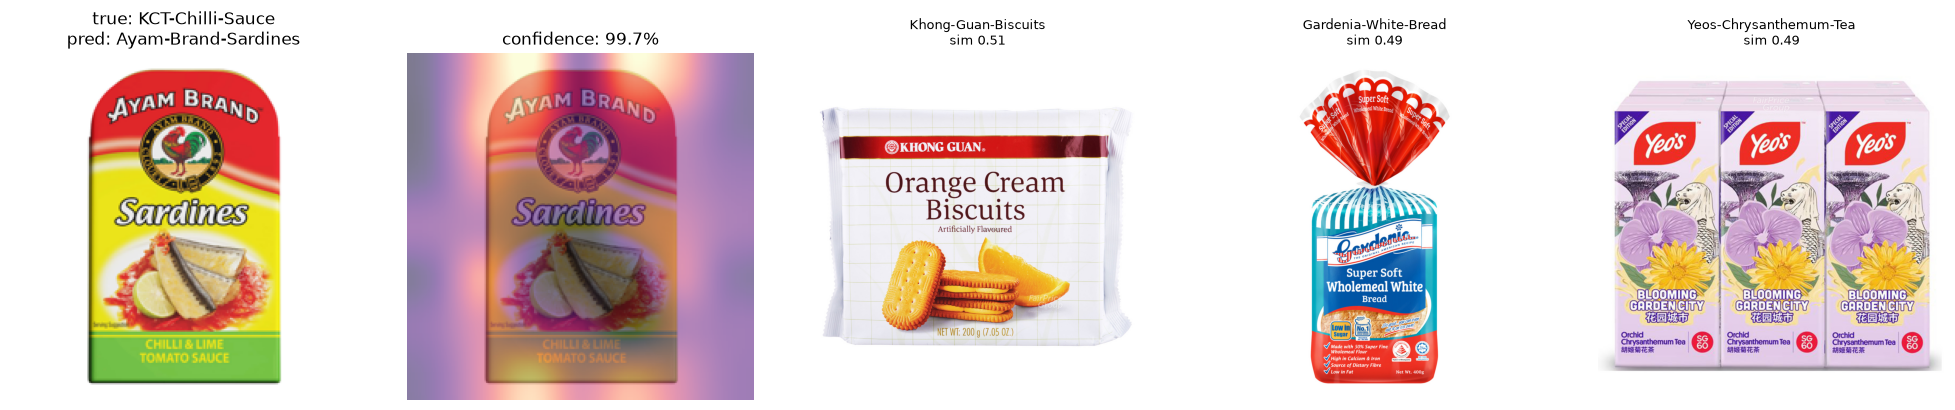

In [11]:
from PIL import Image
import matplotlib.pyplot as plt
# Pick a misread validation image (or the first image if none were misread).
wrong = np.where(val_pred != yval)[0]
target = int(wrong[0]) if len(wrong) else 0
img_path = data.crop_path.iloc[target]
true_name = classes[int(yval[target])]

# Batched occlusion explanation + nearest catalog matches (Hongming's refactor):
# same heatmap as the original cell, ~2 backbone calls instead of 49.
result = explain_prediction(img_path, model, head, classes, gallery=gallery)
plot_explanation(result, true_name=true_name)

# And the recognition-side use of the SAME scoring path: reject-as-unknown.
print(classify_with_confidence(img_path, model, head, classes, threshold=0.5))


## Crop-aware retraining (Hongming's background-false-positive fix)

**What:** Retrain the head on clean studio images **plus** Day 2's real detector crops, then compare before/after explanations on the same misread image.

**Why:** This came from a real failure Hongming observed: the clean-trained head learned a *background shortcut* (the occlusion map lit up background pixels, not the product). Detector crops are off-center, clipped, and background-heavy — training on them teaches the head to ignore background. This is the training-side fix; Day 4's copy-paste augmentation is the data-side fix — they compose.

**Watch for:** crops were already filtered to this catalog's classes upstream, so a bundle holding crops from the *other* dataset can't silently poison training.

crops split: 109 train / 48 held out for Day 5a threshold calibration
combined training pool: 1107 ( 998 clean + 109 real crops )


c:\Users\Max\Desktop\SNAIC_Week4_SmartCart-main\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


crop-aware validation accuracy: 0.913 | clean-only head was 0.92
BEFORE (clean-only head): Ayam-Brand-Sardines 99.7%
AFTER (crop-aware head): Ayam-Brand-Sardines 100.0%


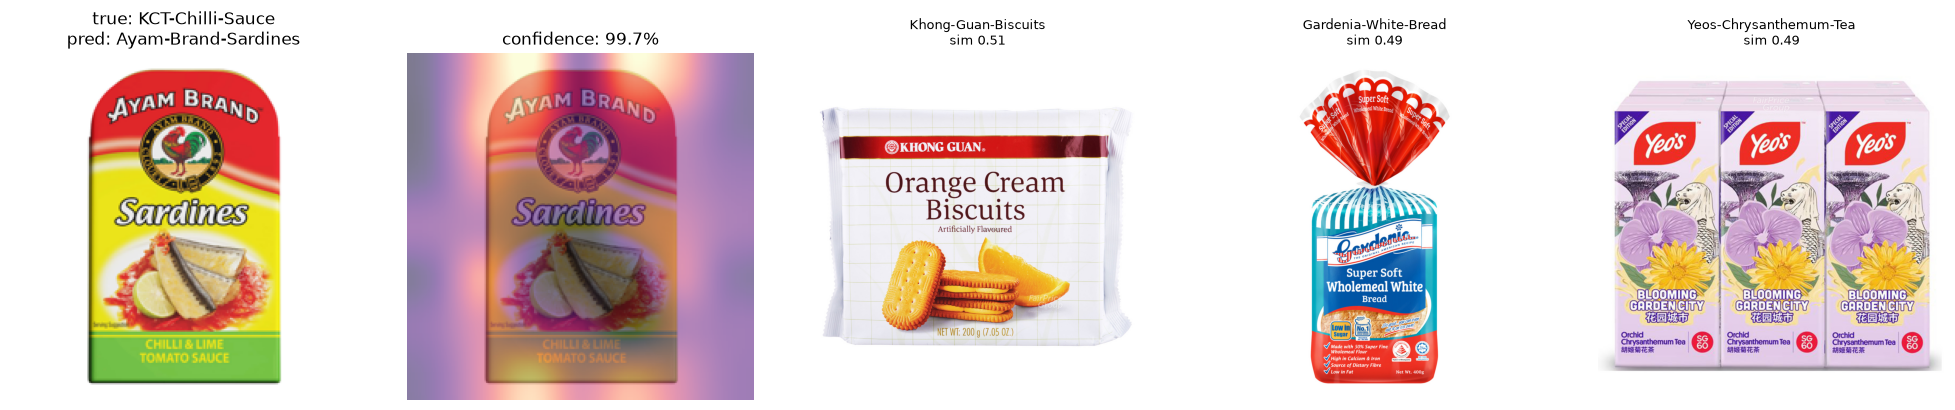

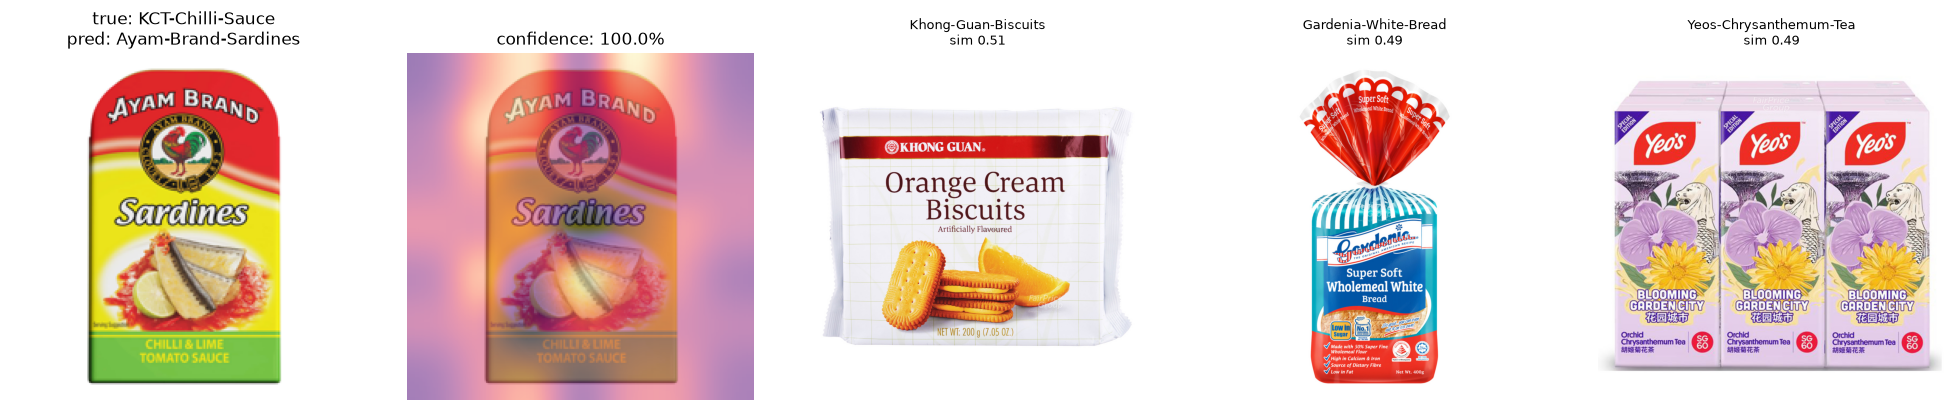

In [12]:
if crops is not None and len(crops):
    # Hold out 30% of the crops BEFORE training touches them. Day 5a calibrates the
    # serving confidence threshold on this held-out set - calibrating on crops the
    # head trained on would show ~100% accuracy at every threshold (memorized) and
    # pick a uselessly low cutoff. Day 4 must use only crops_train too, for the same
    # reason (it retrains head_v2, which Day 5 serves).
    from sklearn.model_selection import train_test_split as _tts
    crops_train, crops_holdout = _tts(crops, test_size=0.3, random_state=0,
                                      stratify=crops.fine if crops.fine.value_counts().min() >= 2 else None)
    b.put_table('crops_train.csv', crops_train[['crop_path', 'fine']])
    b.put_table('calibration_crops.csv', crops_holdout[['crop_path', 'fine']])
    print(f'crops split: {len(crops_train)} train / {len(crops_holdout)} held out for Day 5a threshold calibration')

    combined = pd.concat([data[['crop_path', 'fine']], crops_train[['crop_path', 'fine']]], ignore_index=True)
    combined = combined[combined.fine.isin(classes)]  # keep to the same class set as before
    print('combined training pool:', len(combined), '(', len(data), 'clean +', len(crops_train), 'real crops )')

    feats_combined = feats_of(list(combined.crop_path), model)
    y_combined = np.array([cls_to_i[f] for f in combined.fine])

    counts_c = np.bincount(y_combined, minlength=len(classes))
    strat_c = y_combined if counts_c.min() >= 2 else None
    Xtr_c, Xval_c, ytr_c, yval_c = train_test_split(feats_combined, y_combined, test_size=0.3, random_state=0, stratify=strat_c)

    head_crop_aware = LinearHead(in_dim=feats_combined.shape[1], n_classes=len(classes)).fit(Xtr_c, ytr_c, epochs=200)
    val_pred_c = head_crop_aware.predict(Xval_c)
    acc_c = float((val_pred_c == yval_c).mean())
    print('crop-aware validation accuracy:', round(acc_c, 3), '| clean-only head was', round(acc, 3))

    # Does the crop-aware head change its explanation on the SAME image?
    result_before = explain_prediction(img_path, model, head, classes, gallery=gallery)
    result_after = explain_prediction(img_path, model, head_crop_aware, classes, gallery=gallery)

    print('BEFORE (clean-only head):', result_before['pred_name'], f"{result_before['confidence']:.1%}")
    plot_explanation(result_before, true_name=true_name)

    print('AFTER (crop-aware head):', result_after['pred_name'], f"{result_after['confidence']:.1%}")
    plot_explanation(result_after, true_name=true_name)
else:
    print('no detector crops available - run Day 2 first to enable crop-aware retraining.')


## Save the retrain base pool (for Day 5b v3)

**What:** Persist the exact features + labels this head trained on (and the clean validation split) into the bundle.

**Why:** Day 5b v3's in-app "Retrain model" button refits the linear head on these arrays plus checkout corrections — without needing the image dataset or a Day 3 rerun.

**Watch for:** Labels are saved as string names (not ints) so the class list can grow by appending without breaking older heads.

In [13]:
# Persist the training pool + clean val split so Day 5b v3's in-app retrain can run without the dataset.
base_feats  = feats_combined if 'feats_combined' in dir() else feats
base_names  = (list(combined.fine) if 'feats_combined' in dir() else list(data.fine))
b.put_array('base_feats.npy', base_feats.astype('float32'))
b.put_table('base_labels.csv', pd.DataFrame({'fine': base_names}))
b.put_array('val_feats.npy', Xval.astype('float32'))
b.put_table('val_labels.csv', pd.DataFrame({'fine': [classes[i] for i in yval]}))
save_bundle(b)
print('saved base_feats/base_labels + val_feats/val_labels ->', b.root)

[bundle] saved -> C:\Users\Max\SmartCart_bundle
saved base_feats/base_labels + val_feats/val_labels -> C:\Users\Max\SmartCart_bundle


## Retrain from checkout corrections (Huimin's self-improvement loop)

**What:** The Day 5b v2 app saves every staff-authorized label correction as a crop + true label (`corrections_manifest.csv` in the bundle). This cell folds those corrections back into training — it can even **grow the class list** when a correction names a product the model has never seen, appending an SGD placeholder row to the catalog for any new product — then trains `head_v3` and saves it with its own class list (`class_list_v3.json`).

**Why:** Closes the loop: every checkout mistake a human fixes becomes training signal. Day 5a deploys whichever improved head is newest (`head_v3` → `head_v2` → `head`), so corrections reach production on the next Day 5a run without ever retraining live inside the app.

**Watch for:** New-product placeholder prices are 1.00 SGD with `coarse='New'` — edit `catalog_prices.csv` with the real price. This cell is a no-op until the app has saved at least one correction.

In [14]:
# Adapted from Huimin's Day3 cell 12 (corrections retrain + dynamic class growth).
# Changes for our pipeline: SGD placeholder currency (was USD), head_v3 ships with
# its own class_list_v3.json (so Day 5a can serve it coherently even after class
# growth), and the training pool reuses the crop-aware combined pool from above.
from pathlib import Path

corrections_path = Path(b.root) / 'corrections_manifest.csv'
if corrections_path.exists():
    corr = pd.read_csv(corrections_path).drop_duplicates(subset='crop_path', keep='last')
    corr = corr[corr.crop_path.apply(os.path.exists)]
    print(f'{len(corr)} correction(s) from the checkout app')

    # Corrections may name products the model has never seen -> grow the class list.
    new_classes = sorted(set(corr.fine_true.unique()) - set(classes))
    all_classes = classes + new_classes
    all_cls_to_i = {c: i for i, c in enumerate(all_classes)}
    if new_classes:
        print('NEW products discovered via corrections:', new_classes)
        # Append SGD placeholder rows to the catalog so the app can price them.
        catalog_path = Path(b.root) / 'catalog_prices.csv'
        cat = pd.read_csv(catalog_path)
        missing = [c for c in new_classes if c not in set(cat.fine)]
        if missing:
            cat = pd.concat([cat, pd.DataFrame([{'fine': c, 'coarse': 'New', 'unit_price': 1.00,
                                                 'currency': 'SGD', 'unit': 'each'} for c in missing])],
                            ignore_index=True)
            cat.to_csv(catalog_path, index=False)
            print(f'appended {len(missing)} placeholder row(s) to catalog_prices.csv (1.00 SGD - edit with real prices)')

    # Training pool: crop-aware combined pool if available, else the clean set.
    if 'feats_combined' in dir():
        base_feats, base_y = feats_combined, y_combined
    else:
        base_feats, base_y = feats, y
    corr_feats = feats_of(list(corr.crop_path), model)
    corr_y = np.array([all_cls_to_i[f] for f in corr.fine_true])
    Xtr_v3 = np.concatenate([base_feats, corr_feats])
    ytr_v3 = np.concatenate([base_y, corr_y])

    torch.manual_seed(0)
    head_v3 = LinearHead(in_dim=Xtr_v3.shape[1], n_classes=len(all_classes)).fit(Xtr_v3, ytr_v3, epochs=200)

    # Sanity: the corrections themselves + the clean validation split.
    corr_pred = head_v3.predict(corr_feats)
    corr_acc = float((corr_pred == corr_y).mean())
    val_pred_v3 = head_v3.predict(Xval)
    val_acc_v3 = float((val_pred_v3 == yval).mean())
    print(f'head_v3: corrections learned {corr_acc:.1%} | clean validation {val_acc_v3:.3f} '
          f'| {len(all_classes)} classes ({len(new_classes)} new)')

    save_head(head_v3, str(Path(b.root) / 'head_v3.pt')); b._note('head_v3.pt')
    (Path(b.root) / 'class_list_v3.json').write_text(json.dumps(all_classes))
    b._note('class_list_v3.json')
    save_bundle(b)
    print('saved head_v3.pt + class_list_v3.json - Day 5a will deploy it on its next run')
else:
    print('no corrections yet - run the Day 5b v2 app, correct an item with the staff PIN, then re-run this cell')


no corrections yet - run the Day 5b v2 app, correct an item with the staff PIN, then re-run this cell


## Save + carry forward

**What:** Save the head, the per-class metrics, and a short error report into the bundle.

**Why:** Day 4 reads `head.pt` and `per_class_metrics.csv` to target the weakest classes.

**Watch for:** Confirm head.pt and per_class_metrics.csv are listed in the carry-forward print.

In [15]:
from pathlib import Path
from sklearn.metrics import confusion_matrix

# Use the crop-aware head going forward - falls back to the clean-only head if the
# retraining cell wasn't run, so this cell doesn't hard-fail either way. (Hongming's
# pattern: Day 4/5 load head.pt, so what we save here is what they inherit.)
final_head = head_crop_aware if 'head_crop_aware' in dir() else head
final_val_pred = val_pred_c if 'val_pred_c' in dir() else val_pred
final_yval = yval_c if 'yval_c' in dir() else yval
final_acc = acc_c if 'acc_c' in dir() else acc

# Recompute per-class metrics + hardest confusions against the head actually being
# saved, so per_class_metrics.csv and error_report.md match what Day 4/5 will load.
cm_final = confusion_matrix(final_yval, final_val_pred, labels=list(range(len(classes))))
pcm_final = pd.DataFrame({
    'fine': classes,
    'acc': [cm_final[i, i] / cm_final[i].sum() if cm_final[i].sum() else 0.0 for i in range(len(classes))],
    'n': [int(cm_final[i].sum()) for i in range(len(classes))]})
conf_final = [(classes[i], classes[j], int(cm_final[i, j])) for i in range(len(classes)) for j in range(len(classes)) if i != j and cm_final[i, j] > 0]

save_head(final_head, str(Path(b.root) / 'head.pt')); b._note('head.pt')
b.put_table('per_class_metrics.csv', pcm_final)
worst = pcm_final.sort_values('acc').head(3)
head_kind = 'crop-aware' if 'head_crop_aware' in dir() else 'clean-only'
report = '# SmartCart Day 3 — Error Report\n\n' + \
    f'Validation accuracy: {final_acc:.3f} ({head_kind} head)\n\n## Weakest classes\n\n' + \
    '```\n' + worst.to_string(index=False) + '\n```\n\n## Hardest confusions\n\n' + \
    '\n'.join(f'- {a} -> {bb} ({n})' for a, bb, n in sorted(conf_final, key=lambda t: -t[2])[:5])
(Path(b.root) / 'error_report.md').write_text(report); b._note('error_report.md')
save_bundle(b)
print(f'▶ Carries forward to Day 4: head.pt ({head_kind}) + per_class_metrics.csv')


[bundle] saved -> C:\Users\Max\SmartCart_bundle
▶ Carries forward to Day 4: head.pt (crop-aware) + per_class_metrics.csv
